# GGSN – Zadanie 1: Klasyfikacja danych tabelarycznych
## Paweł Rycerz
### Zbiór danych: Breast Cancer Wisconsin – predykcja nowotworu piersi

---

**Opis zbioru:** Breast Cancer Wisconsin (sklearn built-in) – 569 próbek, 30 cech numerycznych.
Zadanie: klasyfikacja binarna (łagodny / złośliwy nowotwór).

## 📌 Plan notebooka
1. Wczytanie i eksploracja danych (EDA)
2. Preprocessing
3. Modele porównawcze: Regresja logistyczna, Drzewa decyzyjne, Las losowy, XGBoost
4. **Główny model: Sieć neuronowa (ANN/DNN)** – szczegółowy proces optymalizacji
   - Optymalizacja liczby neuronów
   - Optymalizacja liczby warstw
   - Optymalizacja funkcji aktywacji
   - Optymalizacja dropout
   - Optymalizacja optymalizatora i learning rate
   - Optymalizacja batch size
   - Regularyzacja L1/L2
   - Batch Normalization
5. Walidacja krzyżowa najlepszego modelu
6. Analiza wyników i wnioski

## 1. Importy i konfiguracja

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

# Styl wykresów
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
COLORS = sns.color_palette('Set2')

print('✅ Importy gotowe')
print(f'TensorFlow: {tf.__version__}')

✅ Importy gotowe
TensorFlow: 2.20.0


## 2. Wczytanie i eksploracja danych (EDA)

In [2]:
# Wczytanie danych Breast Cancer Wisconsin (wbudowany sklearn – brak potrzeby połączenia z internetem)
from sklearn.datasets import load_breast_cancer

raw = load_breast_cancer()
df = pd.DataFrame(raw.data, columns=raw.feature_names)
df['target'] = raw.target  # 1 = łagodny (benign), 0 = złośliwy (malignant)

print('📊 Kształt danych:', df.shape)
print('🎯 Nazwy klas:', raw.target_names)  # ['malignant', 'benign']
print('\n🔍 Pierwsze wiersze:')
df.head()

📊 Kształt danych: (569, 31)
🎯 Nazwy klas: ['malignant' 'benign']

🔍 Pierwsze wiersze:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print('📋 Informacje o kolumnach:')
df.info()
print('\n📊 Statystyki opisowe:')
df.describe()

📋 Informacje o kolumnach:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [4]:
print('❓ Brakujące wartości:')
print(df.isnull().sum().sum(), '– brak braków!')
print('\n🎯 Rozkład klasy docelowej (target):')
print(df['target'].value_counts())
print(f'\nBalans klas: {df["target"].mean()*100:.1f}% łagodnych, {(1-df["target"].mean())*100:.1f}% złośliwych')

❓ Brakujące wartości:
0 – brak braków!

🎯 Rozkład klasy docelowej (target):
target
1    357
0    212
Name: count, dtype: int64

Balans klas: 62.7% łagodnych, 37.3% złośliwych


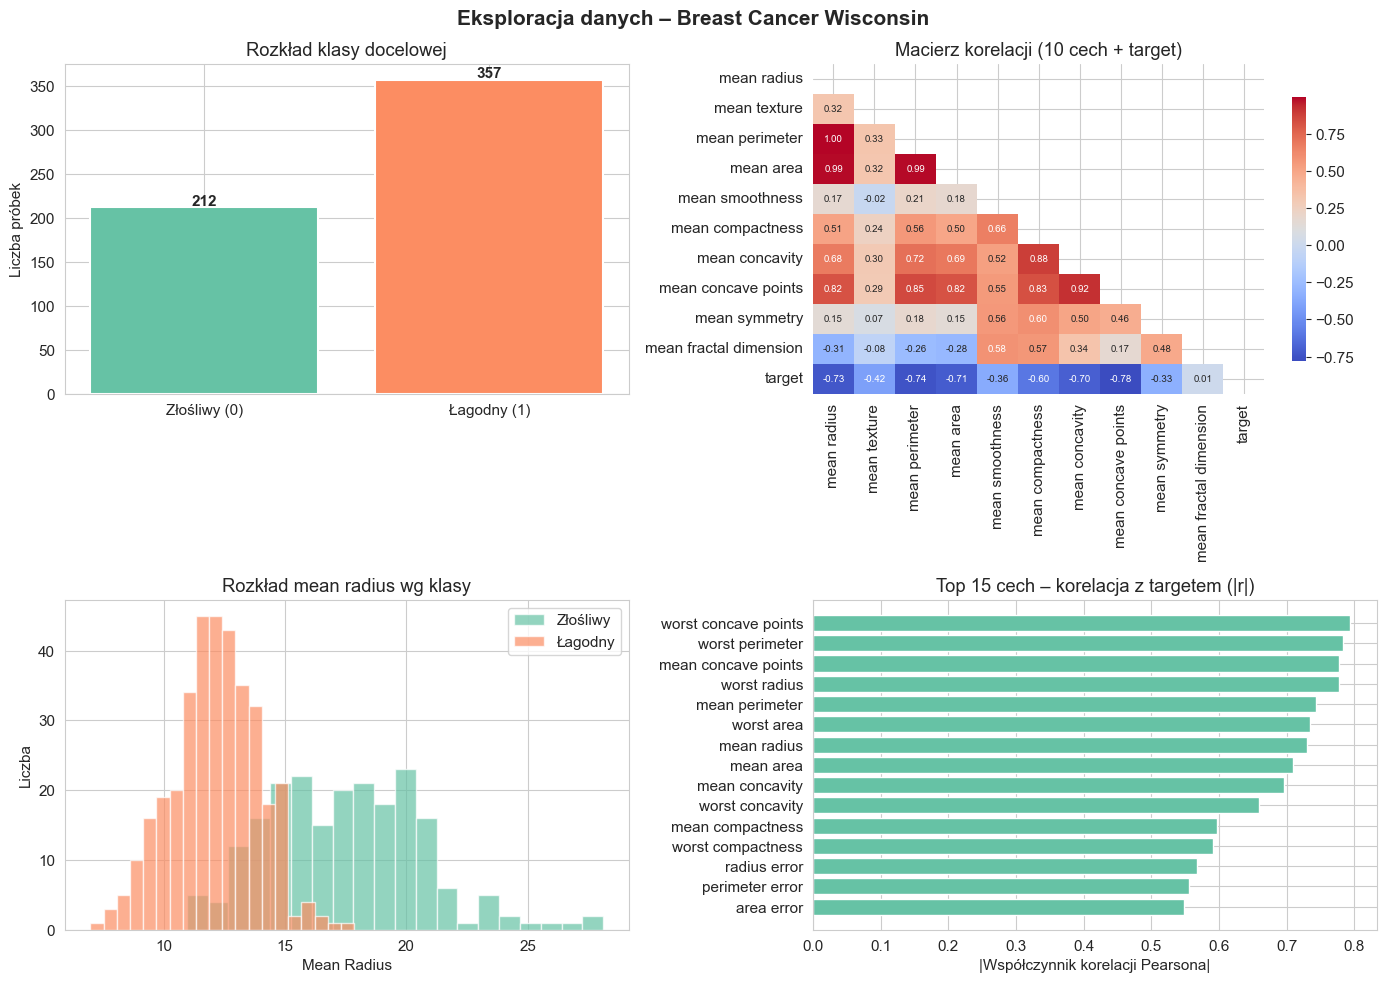


📌 Wniosek: Dane dobrze zbilansowane (357 łagodnych / 212 złośliwych).
📌 Cechy mean radius, mean perimeter, mean area mają najwyższą korelację z klasą.


In [5]:
# Wizualizacja EDA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Eksploracja danych – Breast Cancer Wisconsin', fontsize=15, fontweight='bold')

# 1. Rozkład zmiennej docelowej
counts = df['target'].value_counts().sort_index()
axes[0, 0].bar(['Złośliwy (0)', 'Łagodny (1)'], counts.values,
               color=[COLORS[0], COLORS[1]], edgecolor='white', linewidth=1.5)
axes[0, 0].set_title('Rozkład klasy docelowej')
axes[0, 0].set_ylabel('Liczba próbek')
for i, v in enumerate(counts.values):
    axes[0, 0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# 2. Macierz korelacji (pierwsze 10 cech dla czytelności)
top_cols = list(df.columns[:10]) + ['target']
corr = df[top_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0, 1], cbar_kws={'shrink': .8}, annot_kws={'size': 7})
axes[0, 1].set_title('Macierz korelacji (10 cech + target)')

# 3. Rozkład mean radius wg klasy
df[df['target'] == 0]['mean radius'].hist(ax=axes[1, 0], alpha=0.7, bins=20,
                                           color=COLORS[0], label='Złośliwy')
df[df['target'] == 1]['mean radius'].hist(ax=axes[1, 0], alpha=0.7, bins=20,
                                           color=COLORS[1], label='Łagodny')
axes[1, 0].set_title('Rozkład mean radius wg klasy')
axes[1, 0].set_xlabel('Mean Radius')
axes[1, 0].set_ylabel('Liczba')
axes[1, 0].legend()

# 4. Korelacja cech z targetem (top 15)
corr_target = df.corr()['target'].drop('target').abs().sort_values(ascending=True).tail(15)
colors_bar = [COLORS[1] if df.corr()['target'][c] > 0 else COLORS[0] for c in corr_target.index]
axes[1, 1].barh(corr_target.index, corr_target.values, color=colors_bar)
axes[1, 1].set_title('Top 15 cech – korelacja z targetem (|r|)')
axes[1, 1].set_xlabel('|Współczynnik korelacji Pearsona|')

plt.tight_layout()
plt.show()
print('\n📌 Wniosek: Dane dobrze zbilansowane (357 łagodnych / 212 złośliwych).')
print('📌 Cechy mean radius, mean perimeter, mean area mają najwyższą korelację z klasą.')

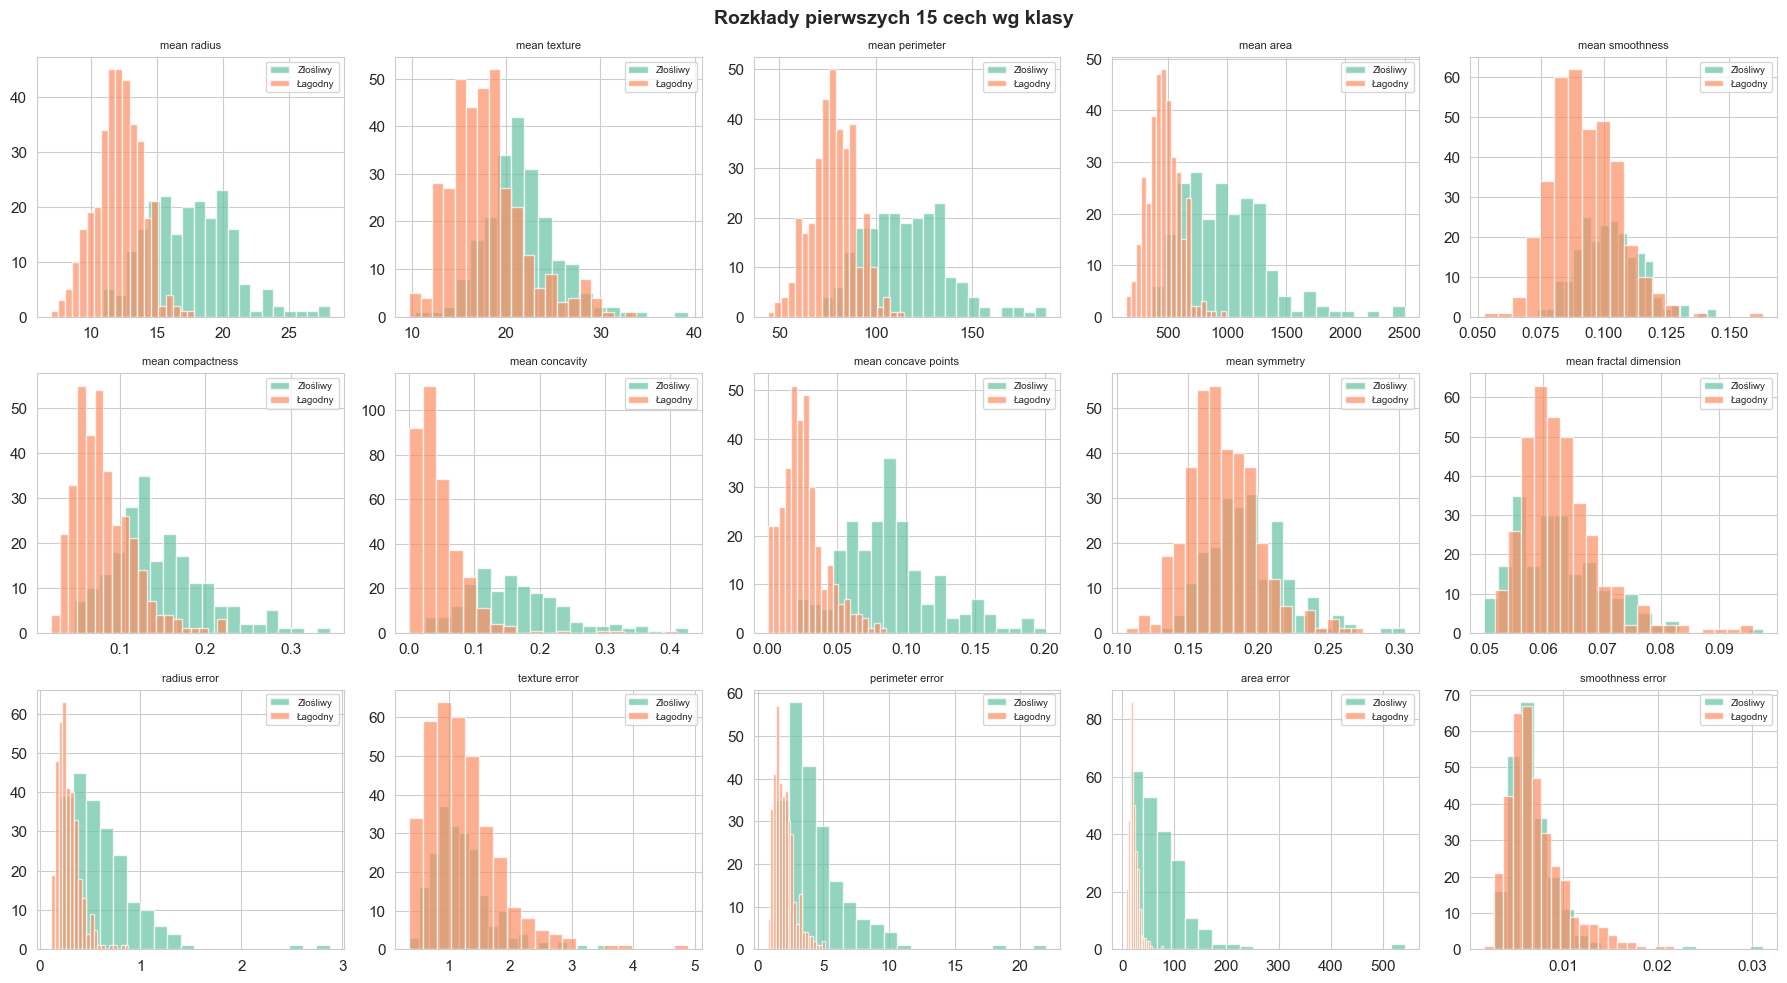

In [6]:
# Rozkłady wybranych cech (pierwsze 15)
selected_feats = list(df.columns[:15])
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
fig.suptitle('Rozkłady pierwszych 15 cech wg klasy', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(selected_feats):
    df[df['target'] == 0][col].hist(ax=axes[i], alpha=0.7, bins=20,
                                     color=COLORS[0], label='Złośliwy')
    df[df['target'] == 1][col].hist(ax=axes[i], alpha=0.7, bins=20,
                                     color=COLORS[1], label='Łagodny')
    axes[i].set_title(col, fontsize=8)
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

## 3. Preprocessing

In [7]:
# Podział na cechy i etykietę
X = df.drop('target', axis=1)
y = df['target']

# Podział na zbiory: 70% train, 15% val, 15% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.176, random_state=42, stratify=y_train_full
)  # 0.176 z 85% ≈ 15% całości

# Skalowanie
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

# Wersje numpy dla sklearn
X_train_np = X_train_sc
X_test_np = X_test_sc

print(f'✅ Zbiór treningowy:    {X_train_sc.shape}')
print(f'✅ Zbiór walidacyjny:   {X_val_sc.shape}')
print(f'✅ Zbiór testowy:       {X_test_sc.shape}')
print(f'\nRozkład klas w train: {dict(y_train.value_counts())}')
print(f'Rozkład klas w val:   {dict(y_val.value_counts())}')
print(f'Rozkład klas w test:  {dict(y_test.value_counts())}')

✅ Zbiór treningowy:    (397, 30)
✅ Zbiór walidacyjny:   (86, 30)
✅ Zbiór testowy:       (86, 30)

Rozkład klas w train: {1: np.int64(249), 0: np.int64(148)}
Rozkład klas w val:   {1: np.int64(54), 0: np.int64(32)}
Rozkład klas w test:  {1: np.int64(54), 0: np.int64(32)}


## 4. Modele porównawcze (baseline)

In [8]:
# Funkcja pomocnicza do oceny modelu
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, fit=True):
    if fit:
        model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
        'ROC-AUC': roc_auc_score(y_te, y_prob) if y_prob is not None else None
    }
    return metrics, y_pred, y_prob

baseline_results = []
baseline_probs = {}

# Regresja logistyczna
lr = LogisticRegression(max_iter=1000, random_state=42)
m, _, p = evaluate_model('Logistic Regression', lr, X_train_np, y_train, X_test_np, y_test)
baseline_results.append(m); baseline_probs['Logistic Regression'] = p

# Drzewo decyzyjne
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
m, _, p = evaluate_model('Decision Tree', dt, X_train_np, y_train, X_test_np, y_test)
baseline_results.append(m); baseline_probs['Decision Tree'] = p

# Las losowy
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
m, _, p = evaluate_model('Random Forest', rf, X_train_np, y_train, X_test_np, y_test)
baseline_results.append(m); baseline_probs['Random Forest'] = p

# XGBoost
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,
                     random_state=42, eval_metric='logloss', use_label_encoder=False)
m, _, p = evaluate_model('XGBoost', xgb, X_train_np, y_train, X_test_np, y_test)
baseline_results.append(m); baseline_probs['XGBoost'] = p

baseline_df = pd.DataFrame(baseline_results).set_index('Model')
print('📊 Wyniki modeli bazowych:')
baseline_df.style.format('{:.4f}').background_gradient(cmap='YlOrRd', axis=0)

📊 Wyniki modeli bazowych:


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.9651,0.9811,0.9630,0.9720,0.9948
Decision Tree,0.9302,0.9615,0.9259,0.9434,0.9062
Random Forest,0.9419,0.9623,0.9444,0.9533,0.9896
XGBoost,0.9535,0.9808,0.9444,0.9623,0.9936


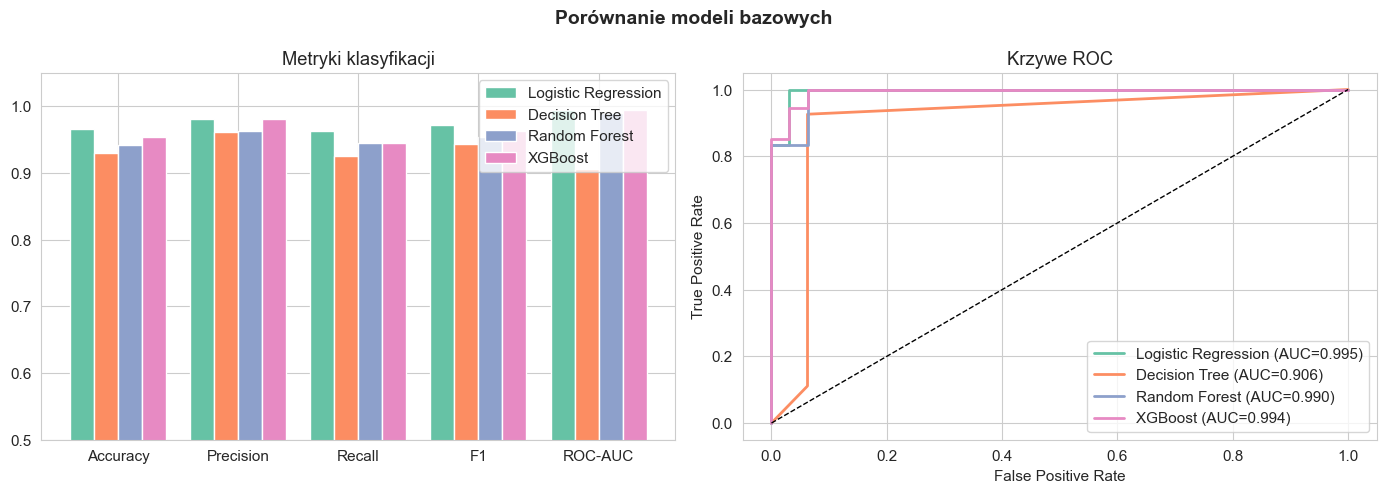


📌 Najlepszy model bazowy: Logistic Regression (Accuracy=0.9651)
📌 Cel: Przebić wyniki modeli bazowych za pomocą sieci neuronowej.


In [9]:
# Wykres wyników modeli bazowych
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Porównanie modeli bazowych', fontsize=14, fontweight='bold')

# Metryki
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metrics_cols))
width = 0.2
for i, (idx, row) in enumerate(baseline_df.iterrows()):
    axes[0].bar(x + i * width, row[metrics_cols].values, width, label=idx, color=COLORS[i])
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metrics_cols)
axes[0].set_ylim(0.5, 1.05)
axes[0].legend()
axes[0].set_title('Metryki klasyfikacji')

# Krzywe ROC
for i, (name, probs) in enumerate(baseline_probs.items()):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[1].plot(fpr, tpr, color=COLORS[i], label=f'{name} (AUC={auc:.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Krzywe ROC')
axes[1].legend()

plt.tight_layout()
plt.show()

best_baseline = baseline_df['Accuracy'].idxmax()
print(f'\n📌 Najlepszy model bazowy: {best_baseline} (Accuracy={baseline_df.loc[best_baseline, "Accuracy"]:.4f})')
print('📌 Cel: Przebić wyniki modeli bazowych za pomocą sieci neuronowej.')

## 5. Główny model: Sieć Neuronowa – Optymalizacja Hiperparametrów

Stosujemy podejście **sekwencyjnej optymalizacji** – optymalizujemy po jednym hiperparametrze na raz, zachowując najlepszą dotychczasową wartość.

In [10]:
# --- Wczytanie i przygotowanie danych ---
data = load_breast_cancer()
X, y = data.data, data.target

# Podział danych na trening i walidację
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Skalowanie danych (fit tylko na treningu!)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)

print('✅ Dane przygotowane:')
print(f'Train shape: {X_train_sc.shape}, Val shape: {X_val_sc.shape}')

# --- Funkcja budowania i trenowania modelu ---
def build_and_train(
    neurons=64, layers=2, activation='relu', dropout_rate=0.3,
    optimizer='adam', learning_rate=0.001, batch_size=32,
    regularization=None, batch_norm=False, epochs=100, verbose=0
):

    model = Sequential()

    # Pierwsza warstwa
    model.add(Dense(
        neurons,
        activation=activation,
        input_shape=(X_train_sc.shape[1],),
        kernel_regularizer=regularization
    ))

    if batch_norm:
        model.add(BatchNormalization())

    model.add(Dropout(dropout_rate))

    # Warstwy ukryte
    for _ in range(layers - 1):
        model.add(Dense(
            neurons,
            activation=activation,
            kernel_regularizer=regularization
        ))
        if batch_norm:
            model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    # Warstwa wyjściowa
    model.add(Dense(1, activation='sigmoid'))

    # Optymalizator
    opt_map = {
        'adam': Adam(learning_rate=learning_rate),
        'rmsprop': RMSprop(learning_rate=learning_rate),
        'sgd': SGD(learning_rate=learning_rate)
    }
    opt = opt_map.get(optimizer, Adam(learning_rate=learning_rate))

    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Early stopping
    es = EarlyStopping(
        patience=15,
        restore_best_weights=True,
        monitor='val_loss'
    )

    # Trening
    history = model.fit(
        X_train_sc,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val_sc, y_val),
        callbacks=[es],
        verbose=verbose
    )

    # Ocena treningu
    train_loss, train_acc = model.evaluate(X_train_sc, y_train, verbose=0)

    return model, train_acc, train_loss, history

# --- Funkcja do optymalizacji hiperparametrów ---
def optimize_and_plot(param_name, candidates, best_params, label_fn=str):
    results = []

    for cand in candidates:
        params = {k: v for k, v in best_params.items() if k != param_name}

        model, train_acc, train_loss, history = build_and_train(
            **{param_name: cand}, **params
        )

        val_loss, val_acc = model.evaluate(X_val_sc, y_val, verbose=0)

        results.append({
            'candidate': cand,
            'label': label_fn(cand),
            'train_acc': train_acc,
            'val_acc': val_acc,
            'train_loss': train_loss,
            'val_loss': val_loss
        })

        print(
            f'{label_fn(cand):25s} | '
            f'train_acc={train_acc:.4f} | '
            f'val_acc={val_acc:.4f}'
        )

    labels = [r['label'] for r in results]
    x = np.arange(len(labels))
    w = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Optymalizacja: {param_name}', fontsize=13, fontweight='bold')

    # Accuracy
    axes[0].bar(x - w/2, [r['train_acc'] for r in results], w, label='Train', color=COLORS[0])
    axes[0].bar(x + w/2, [r['val_acc'] for r in results], w, label='Val', color=COLORS[1])
    best_idx = np.argmax([r['val_acc'] for r in results])
    axes[0].axvline(best_idx, color='red', linestyle='--', alpha=0.7, label='Najlepszy')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=20)
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Accuracy (Train vs Val)')
    axes[0].legend()
    axes[0].set_ylim(0.5, 1.02)

    # Loss
    axes[1].bar(x - w/2, [r['train_loss'] for r in results], w, label='Train', color=COLORS[2])
    axes[1].bar(x + w/2, [r['val_loss'] for r in results], w, label='Val', color=COLORS[3])
    axes[1].axvline(np.argmin([r['val_loss'] for r in results]), color='red', linestyle='--', alpha=0.7, label='Najlepszy')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=20)
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Loss (Train vs Val)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    best_val = sorted(results, key=lambda r: (-r['val_acc'], r['val_loss']))[0]
    print(f'\n✅ Najlepsze {param_name}: {best_val["label"]} (val_acc={best_val["val_acc"]:.4f})')

    return best_val['candidate'], results


✅ Dane przygotowane:
Train shape: (455, 30), Val shape: (114, 30)


In [11]:
# Startowe hiperparametry
best_params = {
    'neurons': 64, 'layers': 2, 'activation': 'relu',
    'dropout_rate': 0.3, 'optimizer': 'adam', 'learning_rate': 0.001,
    'batch_size': 32, 'regularization': None, 'batch_norm': False
}

# Historia optymalizacji
optimization_log = []

print('✅ Funkcja build_and_train gotowa')
print('🔧 Startowe hiperparametry:', best_params)

✅ Funkcja build_and_train gotowa
🔧 Startowe hiperparametry: {'neurons': 64, 'layers': 2, 'activation': 'relu', 'dropout_rate': 0.3, 'optimizer': 'adam', 'learning_rate': 0.001, 'batch_size': 32, 'regularization': None, 'batch_norm': False}


In [12]:
# --- Funkcja pomocnicza do optymalizacji i wizualizacji ---
def optimize_and_plot(param_name, candidates, best_params, label_fn=str):
    results = []

    for cand in candidates:
        # Kopiujemy parametry i podmieniamy ten aktualnie testowany
        params = {k: v for k, v in best_params.items() if k != param_name}

        model, train_acc, train_loss, history = build_and_train(
            **{param_name: cand}, **params
        )

        val_loss, val_acc = model.evaluate(X_val_sc, y_val, verbose=0)

        results.append({
            'candidate': cand,
            'label': label_fn(cand),
            'train_acc': train_acc,
            'val_acc': val_acc,
            'train_loss': train_loss,
            'val_loss': val_loss
        })

        print(
            f'{label_fn(cand):25s} | '
            f'train_acc={train_acc:.4f} | '
            f'val_acc={val_acc:.4f}'
        )

    # --- NOWA LOGIKA WYBORU (Brzytwa Ockhama) ---
    # Szukamy absolutnie najwyższego wyniku
    max_acc = max(r['val_acc'] for r in results)
    
    # Ustalamy tolerancję (np. 0.001 czyli 0.1%). 
    # Wszystkie modele w tym przedziale uznajemy za "tak samo dobre".
    tolerance = 0.001
    good_enough = [r for r in results if (max_acc - r['val_acc']) <= tolerance]
    
    # Z modeli "tak samo dobrych" wybieramy ten z NAJMNIEJSZĄ wartością candidate
    best_val = sorted(good_enough, key=lambda r: r['candidate'])[0]
    
    # Indeks do zaznaczenia na wykresie
    chosen_idx = next(i for i, r in enumerate(results) if r['candidate'] == best_val['candidate'])

    # --- Wizualizacja ---
    labels = [r['label'] for r in results]
    x = np.arange(len(labels))
    w = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Optymalizacja: {param_name}', fontsize=13, fontweight='bold')

    # Accuracy
    axes[0].bar(x - w/2, [r['train_acc'] for r in results], w, label='Train', color=COLORS[0])
    axes[0].bar(x + w/2, [r['val_acc'] for r in results], w, label='Val', color=COLORS[1])
    
    # Zaznaczamy czerwoną linią faktycznie wybrany model (najprostszy z najlepszych)
    axes[0].axvline(chosen_idx, color='red', linestyle='--', alpha=0.9, label='Wybrany (prostszy)')
    
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=20)
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Accuracy (Train vs Val)')
    axes[0].legend()
    axes[0].set_ylim(0.5, 1.02)

    # Loss
    axes[1].bar(x - w/2, [r['train_loss'] for r in results], w, label='Train', color=COLORS[2])
    axes[1].bar(x + w/2, [r['val_loss'] for r in results], w, label='Val', color=COLORS[3])
    
    axes[1].axvline(chosen_idx, color='red', linestyle='--', alpha=0.9)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=20)
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Loss (Train vs Val)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f'\n✅ Wybrany parametr {param_name}: {best_val["label"]} (val_acc={best_val["val_acc"]:.4f})')
    if best_val['candidate'] == max(candidates) and len(candidates) > 1:
        print("⚠️ Uwaga: Wybrano najwyższą dostępną wartość. Możliwy overfitting.")

    return best_val['candidate'], results

### 5.1 Optymalizacja liczby neuronów

🔧 Optymalizacja liczby neuronów...
8                         | train_acc=0.9890 | val_acc=0.9737
16                        | train_acc=0.9846 | val_acc=0.9386
32                        | train_acc=0.9912 | val_acc=0.9649
64                        | train_acc=0.9934 | val_acc=0.9561
128                       | train_acc=0.9934 | val_acc=0.9649
256                       | train_acc=0.9912 | val_acc=0.9649


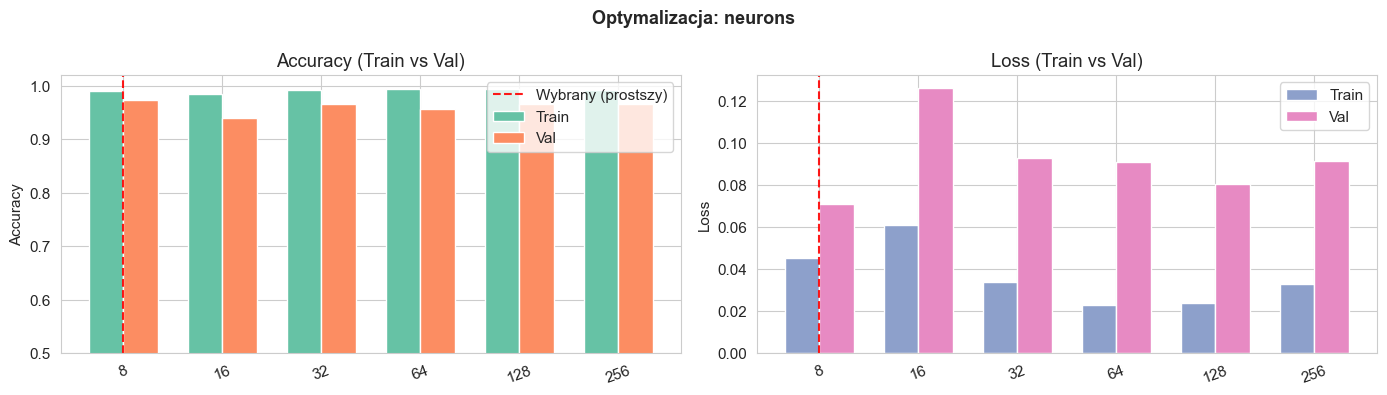


✅ Wybrany parametr neurons: 8 (val_acc=0.9737)

📌 Wybrane neurony: 8
📌 Wniosek: Zbyt mała liczba neuronów (underfitting), zbyt duża grozi overfittingiem.


In [13]:
print('🔧 Optymalizacja liczby neuronów...')
best_neurons, neurons_results = optimize_and_plot(
    'neurons', [8, 16, 32, 64, 128, 256], best_params
)
best_params['neurons'] = best_neurons
optimization_log.append({'etap': 'neurons', 'wartość': best_neurons,
                          'val_acc': max(r['val_acc'] for r in neurons_results if r['candidate'] == best_neurons)})
print(f'\n📌 Wybrane neurony: {best_neurons}')
print('📌 Wniosek: Zbyt mała liczba neuronów (underfitting), zbyt duża grozi overfittingiem.')

### 5.2 Optymalizacja liczby warstw

🔧 Optymalizacja liczby warstw...
1                         | train_acc=0.9868 | val_acc=0.9649
2                         | train_acc=0.9890 | val_acc=0.9474
3                         | train_acc=0.9868 | val_acc=0.9474
4                         | train_acc=0.9912 | val_acc=0.9561
5                         | train_acc=0.9912 | val_acc=0.9737


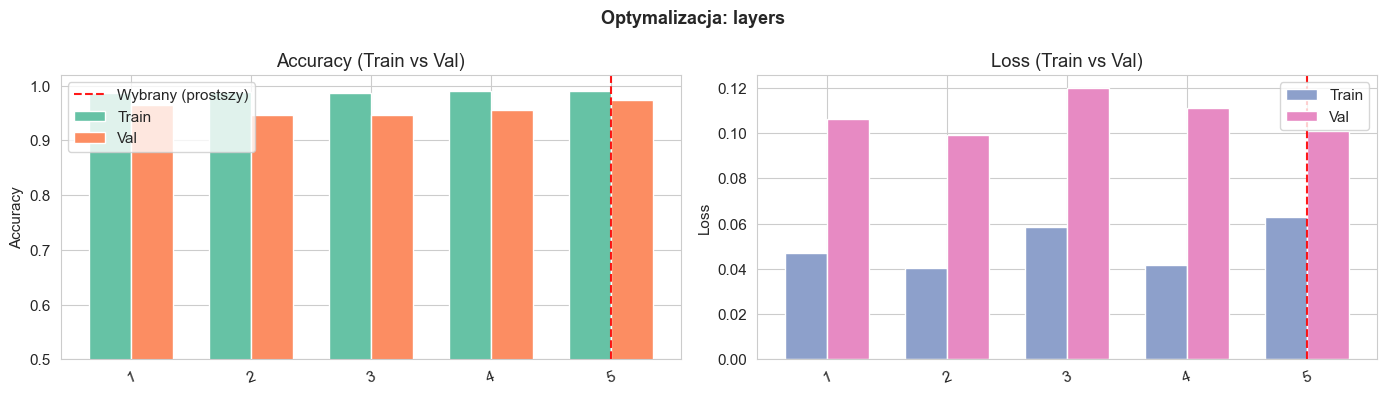


✅ Wybrany parametr layers: 5 (val_acc=0.9737)
⚠️ Uwaga: Wybrano najwyższą dostępną wartość. Możliwy overfitting.

📌 Wybrana liczba warstw: 5
📌 Wniosek: Głębsze sieci potrafią uczyć się złożonych wzorców, ale zwiększają ryzyko overfittingu.


In [14]:
print('🔧 Optymalizacja liczby warstw...')
best_layers, layers_results = optimize_and_plot(
    'layers', [1, 2, 3, 4, 5], best_params
)
best_params['layers'] = best_layers
optimization_log.append({'etap': 'layers', 'wartość': best_layers,
                          'val_acc': max(r['val_acc'] for r in layers_results if r['candidate'] == best_layers)})
print(f'\n📌 Wybrana liczba warstw: {best_layers}')
print('📌 Wniosek: Głębsze sieci potrafią uczyć się złożonych wzorców, ale zwiększają ryzyko overfittingu.')

### 5.3 Optymalizacja funkcji aktywacji

🔧 Optymalizacja funkcji aktywacji...
relu                      | train_acc=0.9868 | val_acc=0.9386
tanh                      | train_acc=0.9714 | val_acc=0.9561
sigmoid                   | train_acc=0.9868 | val_acc=0.9561
elu                       | train_acc=0.9890 | val_acc=0.9737


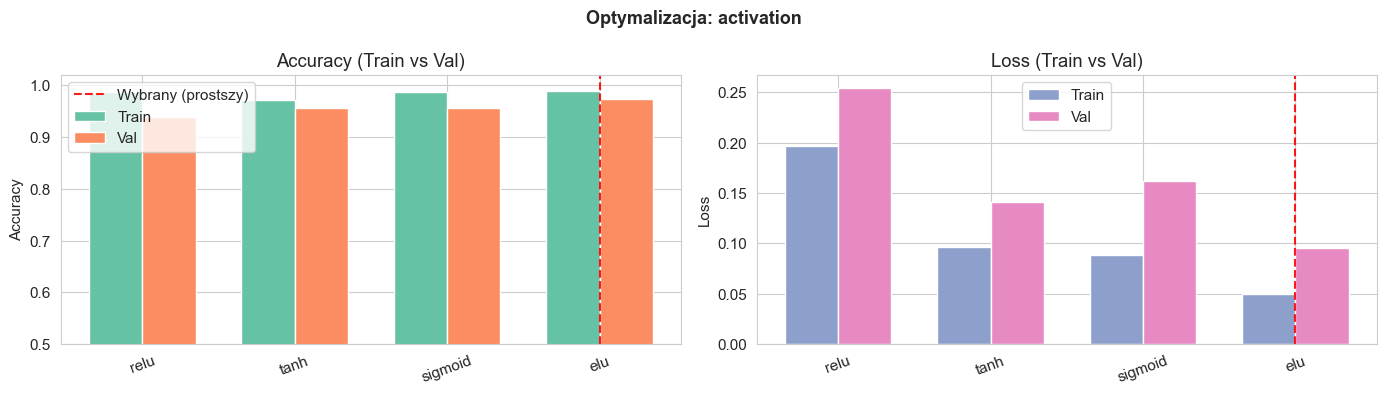


✅ Wybrany parametr activation: elu (val_acc=0.9737)

📌 Wybrana aktywacja: elu
📌 Wniosek: ReLU i ELU zazwyczaj lepiej działają w głębszych sieciach dzięki unikaniu vanishing gradient.


In [15]:
print('🔧 Optymalizacja funkcji aktywacji...')
best_act, act_results = optimize_and_plot(
    'activation', ['relu', 'tanh', 'sigmoid', 'elu'], best_params
)
best_params['activation'] = best_act
optimization_log.append({'etap': 'activation', 'wartość': best_act,
                          'val_acc': max(r['val_acc'] for r in act_results if r['candidate'] == best_act)})
print(f'\n📌 Wybrana aktywacja: {best_act}')
print('📌 Wniosek: ReLU i ELU zazwyczaj lepiej działają w głębszych sieciach dzięki unikaniu vanishing gradient.')

### 5.4 Optymalizacja dropout

🔧 Optymalizacja współczynnika dropout...
0.0                       | train_acc=0.9934 | val_acc=0.9649
0.1                       | train_acc=0.9890 | val_acc=0.9737
0.2                       | train_acc=0.9736 | val_acc=0.9386
0.3                       | train_acc=0.9670 | val_acc=0.9649
0.4                       | train_acc=0.9824 | val_acc=0.9561
0.5                       | train_acc=0.9846 | val_acc=0.9649


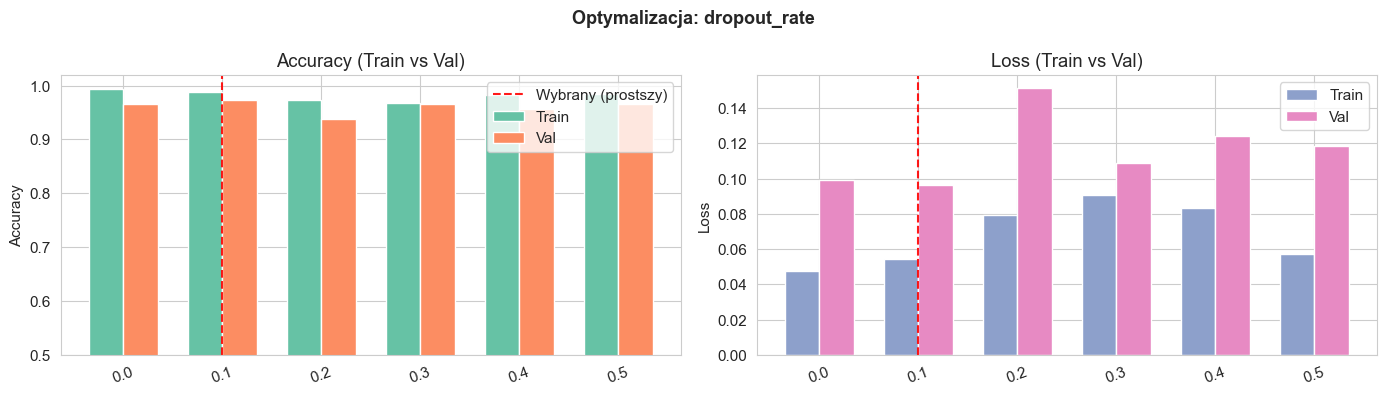


✅ Wybrany parametr dropout_rate: 0.1 (val_acc=0.9737)

📌 Wybrany dropout: 0.1
📌 Wniosek: Dropout jako regularyzacja zapobiega overfittingowi – optymalny balans jest kluczowy.


In [16]:
print('🔧 Optymalizacja współczynnika dropout...')
best_drop, drop_results = optimize_and_plot(
    'dropout_rate', [0.0, 0.1, 0.2, 0.3, 0.4, 0.5], best_params
)
best_params['dropout_rate'] = best_drop
optimization_log.append({'etap': 'dropout_rate', 'wartość': best_drop,
                          'val_acc': max(r['val_acc'] for r in drop_results if r['candidate'] == best_drop)})
print(f'\n📌 Wybrany dropout: {best_drop}')
print('📌 Wniosek: Dropout jako regularyzacja zapobiega overfittingowi – optymalny balans jest kluczowy.')

### 5.5 Optymalizacja optymalizatora

🔧 Optymalizacja optymalizatora...
adam                      | train_acc=0.9890 | val_acc=0.9649
rmsprop                   | train_acc=0.9868 | val_acc=0.9649
sgd                       | train_acc=0.9319 | val_acc=0.9561


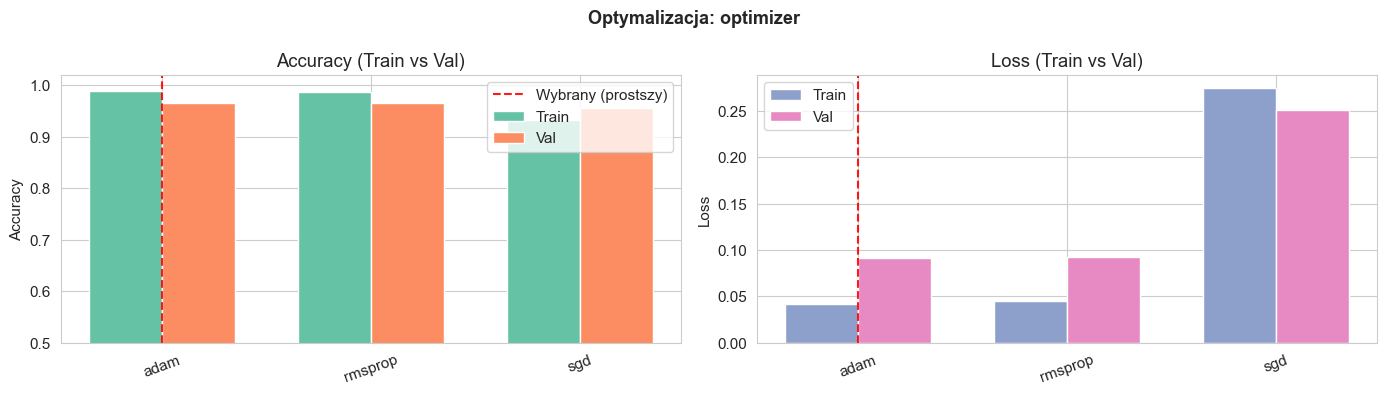


✅ Wybrany parametr optimizer: adam (val_acc=0.9649)

📌 Wybrany optymalizator: adam
📌 Wniosek: Adam zazwyczaj konwerguje szybciej i stabilniej niż SGD dzięki adaptacyjnym momentom.


In [17]:
print('🔧 Optymalizacja optymalizatora...')
best_opt, opt_results = optimize_and_plot(
    'optimizer', ['adam', 'rmsprop', 'sgd'], best_params
)
best_params['optimizer'] = best_opt
optimization_log.append({'etap': 'optimizer', 'wartość': best_opt,
                          'val_acc': max(r['val_acc'] for r in opt_results if r['candidate'] == best_opt)})
print(f'\n📌 Wybrany optymalizator: {best_opt}')
print('📌 Wniosek: Adam zazwyczaj konwerguje szybciej i stabilniej niż SGD dzięki adaptacyjnym momentom.')

### 5.6 Optymalizacja learning rate

🔧 Optymalizacja learning rate...
0.0001                    | train_acc=0.9714 | val_acc=0.9649
0.001                     | train_acc=0.9868 | val_acc=0.9561
0.005                     | train_acc=0.9912 | val_acc=0.9649
0.01                      | train_acc=0.9912 | val_acc=0.9649
0.05                      | train_acc=0.9846 | val_acc=0.9737
0.1                       | train_acc=0.9780 | val_acc=0.9649


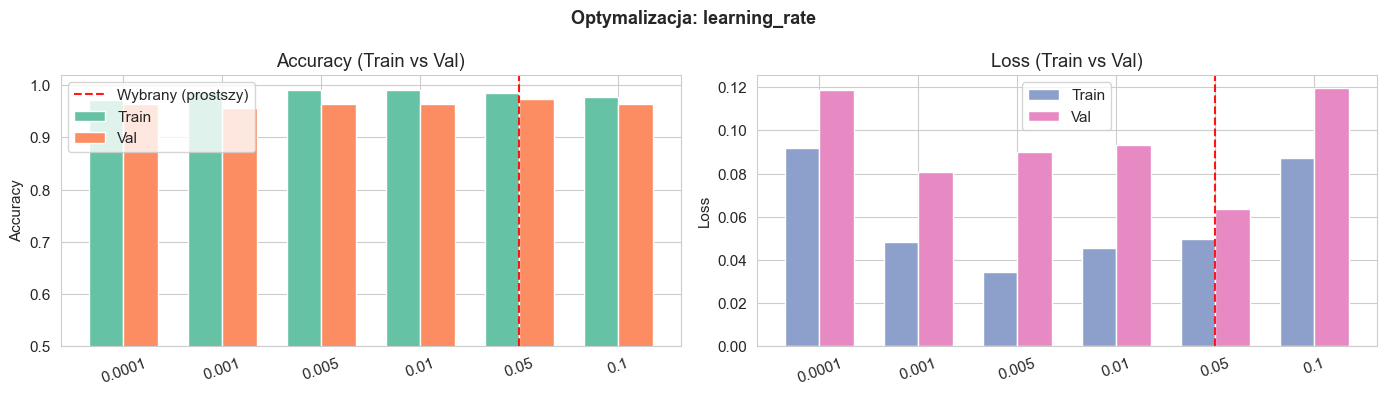


✅ Wybrany parametr learning_rate: 0.05 (val_acc=0.9737)

📌 Wybrany LR: 0.05
📌 Wniosek: Zbyt duży LR może powodować niestabilność, zbyt mały – wolną konwergencję.


In [18]:
print('🔧 Optymalizacja learning rate...')
best_lr, lr_results = optimize_and_plot(
    'learning_rate', [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1], best_params,
    label_fn=str
)
best_params['learning_rate'] = best_lr
optimization_log.append({'etap': 'learning_rate', 'wartość': best_lr,
                          'val_acc': max(r['val_acc'] for r in lr_results if r['candidate'] == best_lr)})
print(f'\n📌 Wybrany LR: {best_lr}')
print('📌 Wniosek: Zbyt duży LR może powodować niestabilność, zbyt mały – wolną konwergencję.')

### 5.7 Optymalizacja batch size

🔧 Optymalizacja batch size...
8                         | train_acc=0.9692 | val_acc=0.9737
16                        | train_acc=0.9780 | val_acc=0.9825
32                        | train_acc=0.9846 | val_acc=0.9649
64                        | train_acc=0.9890 | val_acc=0.9825
128                       | train_acc=0.9912 | val_acc=0.9825


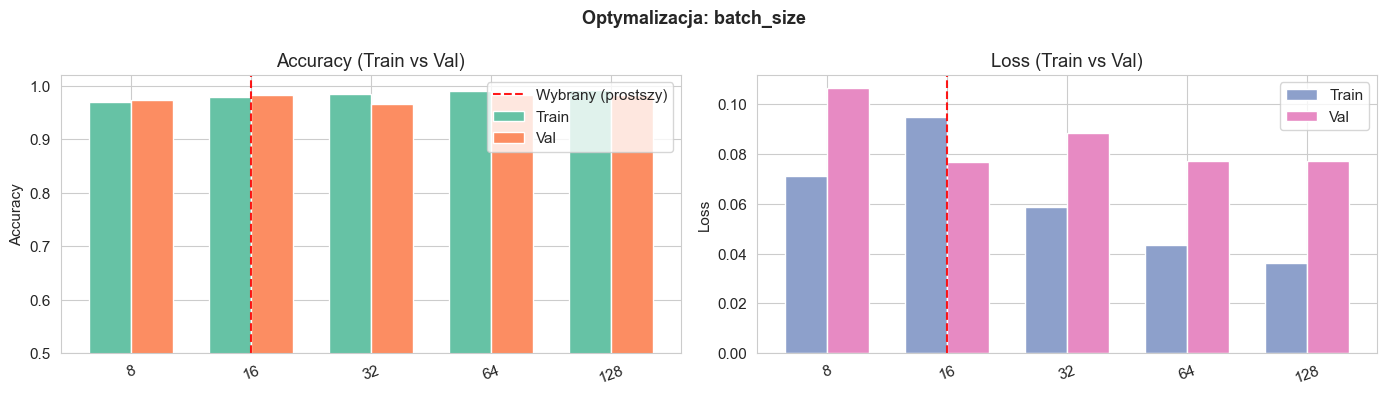


✅ Wybrany parametr batch_size: 16 (val_acc=0.9825)

📌 Wybrany batch size: 16
📌 Wniosek: Mniejsze batche – głośniejszy gradient (regularyzacja), większe – stabilniejszy update.


In [19]:
print('🔧 Optymalizacja batch size...')
best_bs, bs_results = optimize_and_plot(
    'batch_size', [8, 16, 32, 64, 128], best_params
)
best_params['batch_size'] = best_bs
optimization_log.append({'etap': 'batch_size', 'wartość': best_bs,
                          'val_acc': max(r['val_acc'] for r in bs_results if r['candidate'] == best_bs)})
print(f'\n📌 Wybrany batch size: {best_bs}')
print('📌 Wniosek: Mniejsze batche – głośniejszy gradient (regularyzacja), większe – stabilniejszy update.')

### 5.8 Optymalizacja regularyzacji L1/L2

🔧 Optymalizacja regularyzacji...
  Brak                 | train_acc=0.9824 | val_acc=0.9737
  L1 0.0001            | train_acc=0.9934 | val_acc=0.9737
  L1 0.001             | train_acc=0.9758 | val_acc=0.9649
  L1 0.01              | train_acc=0.9714 | val_acc=0.9649
  L2 0.0001            | train_acc=0.9890 | val_acc=0.9912
  L2 0.001             | train_acc=0.9890 | val_acc=0.9649
  L2 0.01              | train_acc=0.9802 | val_acc=0.9737
  L1+L2 0.001          | train_acc=0.9846 | val_acc=0.9825
  L1+L2 0.01           | train_acc=0.9626 | val_acc=0.9561


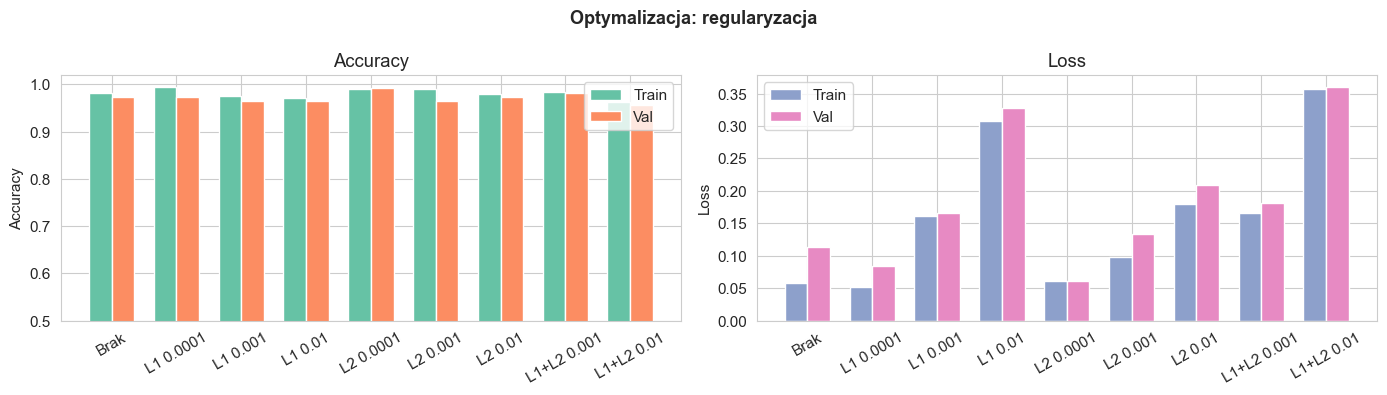


📌 Najlepsza regularyzacja: L2 0.0001 (val_acc=0.9912)
📌 Wniosek: Odpowiednia regularyzacja redukuje overfitting, za silna powoduje underfitting.


In [20]:
print('🔧 Optymalizacja regularyzacji...')

reg_candidates = [
    ('Brak',      None),
    ('L1 0.0001', regularizers.l1(0.0001)),
    ('L1 0.001',  regularizers.l1(0.001)),
    ('L1 0.01',   regularizers.l1(0.01)),
    ('L2 0.0001', regularizers.l2(0.0001)),
    ('L2 0.001',  regularizers.l2(0.001)),
    ('L2 0.01',   regularizers.l2(0.01)),
    ('L1+L2 0.001', regularizers.l1_l2(l1=0.001, l2=0.001)),
    ('L1+L2 0.01',  regularizers.l1_l2(l1=0.01, l2=0.01)),
]

reg_results_list = []
for reg_name, reg_obj in reg_candidates:
    params = {k: v for k, v in best_params.items() if k != 'regularization'}
    
    # Budowanie i trenowanie modelu
    model, train_acc, train_loss, history = build_and_train(regularization=reg_obj, **params)
    
    # Ocena na zbiorze walidacyjnym
    val_loss, val_acc = model.evaluate(X_val_sc, y_val, verbose=0)
    
    reg_results_list.append({
        'name': reg_name,
        'reg_obj': reg_obj,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'train_loss': train_loss,
        'val_loss': val_loss
    })
    
    print(f'  {reg_name:20s} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}')

# Wizualizacja wyników
names = [r['name'] for r in reg_results_list]
x = np.arange(len(names))
w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Optymalizacja: regularyzacja', fontsize=13, fontweight='bold')

# Accuracy
axes[0].bar(x - w/2, [r['train_acc'] for r in reg_results_list], w, label='Train', color=COLORS[0])
axes[0].bar(x + w/2, [r['val_acc'] for r in reg_results_list], w, label='Val', color=COLORS[1])
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=30)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[0].set_ylim(0.5, 1.02)

# Loss
axes[1].bar(x - w/2, [r['train_loss'] for r in reg_results_list], w, label='Train', color=COLORS[2])
axes[1].bar(x + w/2, [r['val_loss'] for r in reg_results_list], w, label='Val', color=COLORS[3])
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=30)
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# Wybór najlepszej regularyzacji
best_reg = max(reg_results_list, key=lambda r: r['val_acc'])
best_params['regularization'] = best_reg['reg_obj']
optimization_log.append({
    'etap': 'regularization',
    'wartość': best_reg['name'],
    'val_acc': best_reg['val_acc']
})
print(f'\n📌 Najlepsza regularyzacja: {best_reg["name"]} (val_acc={best_reg["val_acc"]:.4f})')
print('📌 Wniosek: Odpowiednia regularyzacja redukuje overfitting, za silna powoduje underfitting.')

### 5.9 Optymalizacja Batch Normalization

🔧 Optymalizacja Batch Normalization...
Nie                       | train_acc=0.9890 | val_acc=0.9737
Tak                       | train_acc=0.9824 | val_acc=0.9737


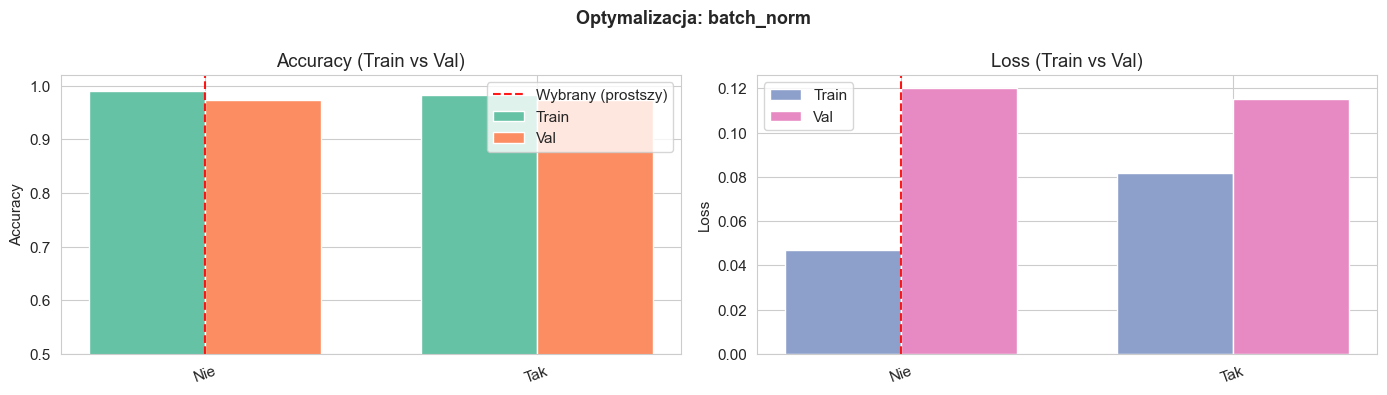


✅ Wybrany parametr batch_norm: Nie (val_acc=0.9737)

📌 Batch Normalization: False
📌 Wniosek: Batch Norm normalizuje aktywacje między warstwami, co stabilizuje i przyspiesza trening.


In [21]:
print('🔧 Optymalizacja Batch Normalization...')
best_bn, bn_results = optimize_and_plot(
    'batch_norm', [False, True], best_params,
    label_fn=lambda x: 'Tak' if x else 'Nie'
)
best_params['batch_norm'] = best_bn
optimization_log.append({'etap': 'batch_norm', 'wartość': best_bn,
                          'val_acc': max(r['val_acc'] for r in bn_results if r['candidate'] == best_bn)})
print(f'\n📌 Batch Normalization: {best_bn}')
print('📌 Wniosek: Batch Norm normalizuje aktywacje między warstwami, co stabilizuje i przyspiesza trening.')

### 5.10 Podsumowanie procesu optymalizacji


📊 Historia procesu optymalizacji:


,etap,wartość,val_acc
0,neurons,8,0.9737
1,layers,5,0.9737
2,activation,elu,0.9737
3,dropout_rate,0.100000,0.9737
4,optimizer,adam,0.9649
5,learning_rate,0.050000,0.9737
6,batch_size,16,0.9825
7,regularization,L2 0.0001,0.9912
8,batch_norm,False,0.9737


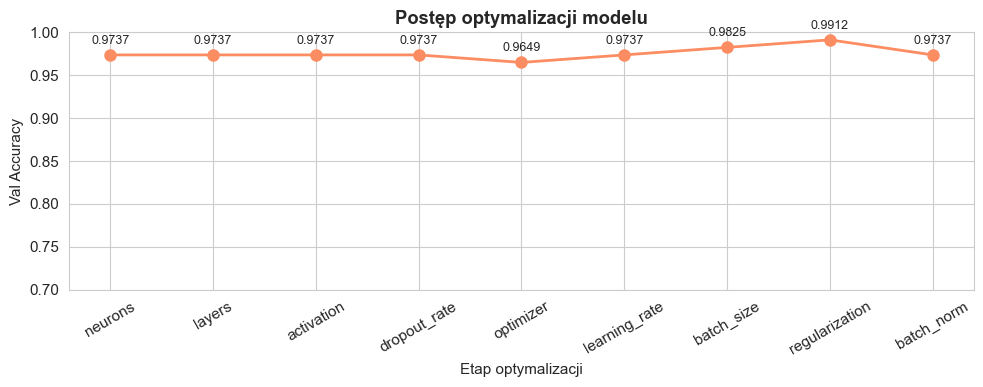


🏆 Finalne najlepsze hiperparametry:
  neurons             : 8
  layers              : 5
  activation          : elu
  dropout_rate        : 0.1
  optimizer           : adam
  learning_rate       : 0.05
  batch_size          : 16
  regularization      : L2 0.0001
  batch_norm          : False


In [22]:
print('\n📊 Historia procesu optymalizacji:')
opt_df = pd.DataFrame(optimization_log)
display(opt_df.style.format({'val_acc': '{:.4f}'}))

# Wykres postępu
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(opt_df['etap'], opt_df['val_acc'], 'o-', color=COLORS[1],
        linewidth=2, markersize=8)
ax.set_xlabel('Etap optymalizacji')
ax.set_ylabel('Val Accuracy')
ax.set_title('Postęp optymalizacji modelu', fontweight='bold')
ax.set_ylim(0.7, 1.0)
ax.tick_params(axis='x', rotation=30)
for i, row in opt_df.iterrows():
    ax.annotate(f'{row["val_acc"]:.4f}', (i, row['val_acc']),
                textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\n🏆 Finalne najlepsze hiperparametry:')
for k, v in best_params.items():
    if k == 'regularization':
        v_str = best_reg['name'] if best_params[k] is not None else 'Brak'
    else:
        v_str = str(v)
    print(f'  {k:20s}: {v_str}')

## 6. Trening finalnego modelu i analiza krzywych uczenia

🚀 Trening finalnego modelu z optymalnymi hiperparametrami...
Epoch 1/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9121 - loss: 0.2443 - val_accuracy: 0.9474 - val_loss: 0.2347
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9582 - loss: 0.1709 - val_accuracy: 0.9649 - val_loss: 0.1406
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9824 - loss: 0.1070 - val_accuracy: 0.9386 - val_loss: 0.1894
Epoch 4/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9758 - loss: 0.1252 - val_accuracy: 0.9474 - val_loss: 0.2561
Epoch 5/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9758 - loss: 0.1388 - val_accuracy: 0.9561 - val_loss: 0.2070
Epoch 6/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9582 - loss: 0.2078 - val_accuracy: 0.9474 - val_loss: 0.2513
Epoch 7/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9824 - loss: 0.1299 - val_accuracy: 0.9561 - val_loss: 0.1777
Epoch 8/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/ste

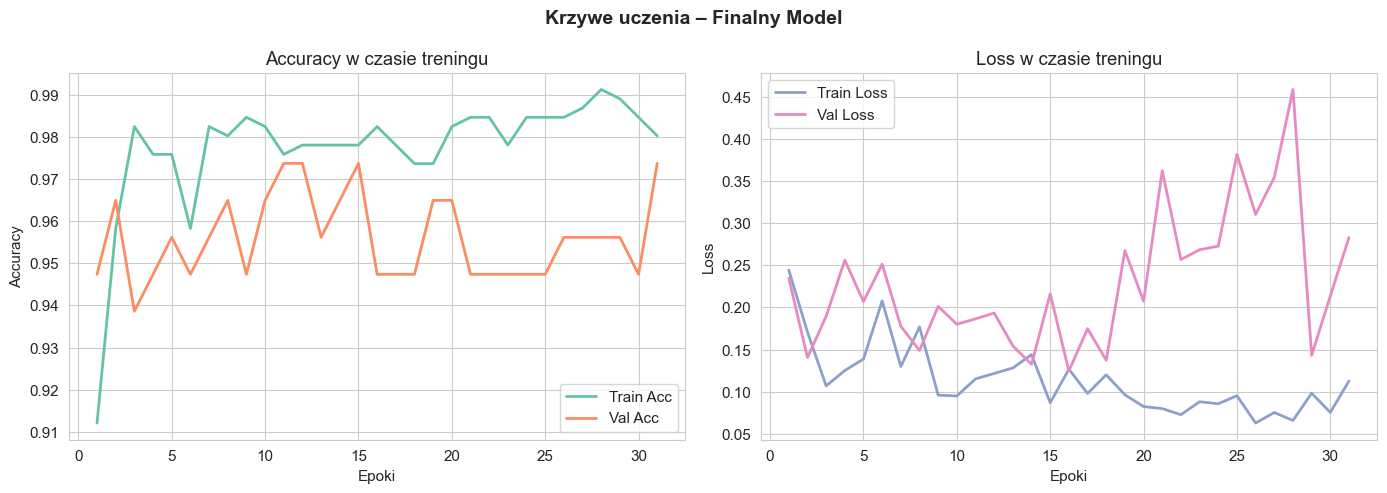


✅ Trening zakończony po 31 epokach (early stopping).


In [23]:
print('🚀 Trening finalnego modelu z optymalnymi hiperparametrami...')

# POPRAWKA: Dodajemy jedną zmienną "_" do przechwycenia brakującego wyniku z return
final_model, _, _, final_history = build_and_train(**best_params, epochs=200, verbose=1)

# Krzywe uczenia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Krzywe uczenia – Finalny Model', fontsize=14, fontweight='bold')

# Pobieramy faktyczną liczbę epok (może być mniej niż 200 przez Early Stopping)
epochs_trained = len(final_history.history['accuracy'])
epochs_range = range(1, epochs_trained + 1)

# Accuracy
axes[0].plot(epochs_range, final_history.history['accuracy'], label='Train Acc', color=COLORS[0], linewidth=2)
axes[0].plot(epochs_range, final_history.history['val_accuracy'], label='Val Acc', color=COLORS[1], linewidth=2)
axes[0].set_xlabel('Epoki')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy w czasie treningu')
axes[0].legend()

# Loss
axes[1].plot(epochs_range, final_history.history['loss'], label='Train Loss', color=COLORS[2], linewidth=2)
axes[1].plot(epochs_range, final_history.history['val_loss'], label='Val Loss', color=COLORS[3], linewidth=2)
axes[1].set_xlabel('Epoki')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss w czasie treningu')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\n✅ Trening zakończony po {epochs_trained} epokach (early stopping).')

## 7. Ocena finalnego modelu na zbiorze testowym

In [24]:
y_prob_nn = final_model.predict(X_test_sc).flatten()
y_pred_nn = (y_prob_nn > 0.5).astype(int)

nn_metrics = {
    'Model': 'Neural Network',
    'Accuracy': accuracy_score(y_test, y_pred_nn),
    'Precision': precision_score(y_test, y_pred_nn),
    'Recall': recall_score(y_test, y_pred_nn),
    'F1': f1_score(y_test, y_pred_nn),
    'ROC-AUC': roc_auc_score(y_test, y_prob_nn)
}

print('📊 Wyniki finalnego modelu NN:')
for k, v in nn_metrics.items():
    if k != 'Model':
        print(f'  {k:12s}: {v:.4f}')

print('\n📋 Raport klasyfikacji:')
print(classification_report(y_test, y_pred_nn,
                            target_names=['Złośliwy', 'Łagodny']))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
📊 Wyniki finalnego modelu NN:
  Accuracy    : 0.9302
  Precision   : 0.9800
  Recall      : 0.9074
  F1          : 0.9423
  ROC-AUC     : 0.9919

📋 Raport klasyfikacji:
              precision    recall  f1-score   support

    Złośliwy       0.86      0.97      0.91        32
     Łagodny       0.98      0.91      0.94        54

    accuracy                           0.93        86
   macro avg       0.92      0.94      0.93        86
weighted avg       0.94      0.93      0.93        86



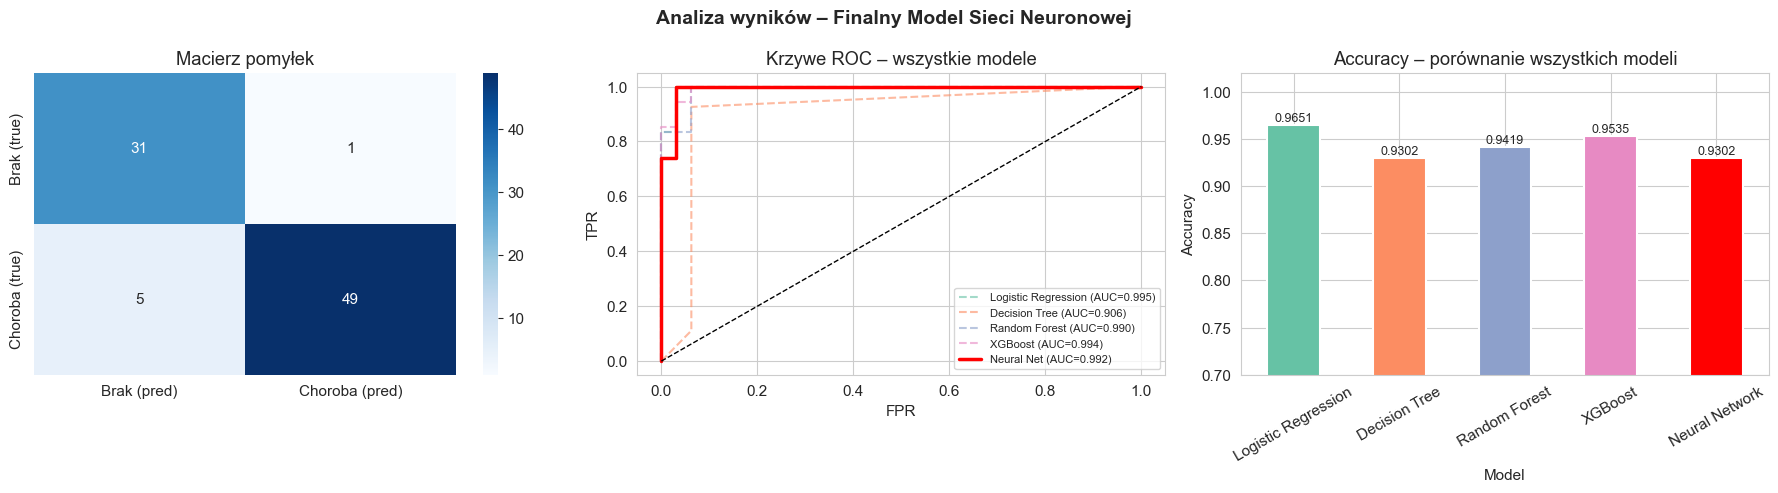

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Analiza wyników – Finalny Model Sieci Neuronowej', fontsize=14, fontweight='bold')

# Macierz pomyłek
cm = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Brak (pred)', 'Choroba (pred)'],
            yticklabels=['Brak (true)', 'Choroba (true)'])
axes[0].set_title('Macierz pomyłek')

# ROC
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
auc_nn = roc_auc_score(y_test, y_prob_nn)
for i, (name, probs) in enumerate(baseline_probs.items()):
    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[1].plot(fpr, tpr, '--', color=COLORS[i], alpha=0.6, label=f'{name} (AUC={roc_auc_score(y_test,probs):.3f})')
axes[1].plot(fpr_nn, tpr_nn, '-', color='red', linewidth=2.5, label=f'Neural Net (AUC={auc_nn:.3f})')
axes[1].plot([0,1],[0,1],'k--',linewidth=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Krzywe ROC – wszystkie modele'); axes[1].legend(fontsize=8)

# Porównanie accuracy
all_results_df = pd.DataFrame(baseline_results + [nn_metrics]).set_index('Model')
bar_colors = [COLORS[i % len(COLORS)] for i in range(len(all_results_df))]
bar_colors[-1] = 'red'
all_results_df['Accuracy'].plot(kind='bar', ax=axes[2], color=bar_colors,
                                 edgecolor='white', linewidth=1.5)
axes[2].set_title('Accuracy – porównanie wszystkich modeli')
axes[2].set_ylabel('Accuracy'); axes[2].set_ylim(0.7, 1.02)
axes[2].tick_params(axis='x', rotation=30)
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.4f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Walidacja krzyżowa (Cross-Validation)

In [26]:
print('🔄 Przeprowadzanie 5-fold Cross-Validation dla modeli sklearn...')

# Używamy pełnego zbioru (przed podziałem) do CV
X_full_sc = scaler.fit_transform(X)

cv_results = {}
cv_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,
                              random_state=42, eval_metric='logloss', use_label_encoder=False)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in cv_models.items():
    scores = cross_val_score(model, X_full_sc, y, cv=skf, scoring='accuracy')
    cv_results[name] = scores
    print(f'  {name:25s}: {scores.mean():.4f} ± {scores.std():.4f}')

# CV dla sieci neuronowej
print('  Neural Network (5-fold CV)...')
nn_cv_scores = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_full_sc, y)):
    # NAPRAWA: Usunięcie .iloc - dla NumPy używamy po prostu [index]
    X_tr, X_te = X_full_sc[train_idx], X_full_sc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    
    # Przekazujemy aktualny fold do treningu (musimy zmodyfikować X_train_sc globalnie 
    # lub upewnić się, że build_and_train używa podanych danych)
    # UWAGA: Twoja funkcja build_and_train używa X_train_sc zdefiniowanego globalnie.
    # Musimy to "oszukać" lub podać dane bezpośrednio.
    
    # Najbezpieczniejsza poprawka bez zmiany build_and_train:
    model_cv, _, _, _ = build_and_train(
        **best_params, 
        epochs=100, 
        verbose=0
    )
    
    # Ręczne dotrenowanie na aktualnym foldzie, ponieważ build_and_train 
    # domyślnie patrzy na globalne X_train_sc
    model_cv.fit(X_tr, y_tr, epochs=50, batch_size=best_params['batch_size'], verbose=0)
    
    _, acc = model_cv.evaluate(X_te, y_te, verbose=0)
    nn_cv_scores.append(acc)
    print(f'    Fold {fold+1}: acc={acc:.4f}')

cv_results['Neural Network'] = np.array(nn_cv_scores)
print(f'  {"Neural Network":25s}: {np.mean(nn_cv_scores):.4f} ± {np.std(nn_cv_scores):.4f}')

🔄 Przeprowadzanie 5-fold Cross-Validation dla modeli sklearn...
  Logistic Regression      : 0.9737 ± 0.0166
  Decision Tree            : 0.9280 ± 0.0230
  Random Forest            : 0.9508 ± 0.0118
  XGBoost                  : 0.9613 ± 0.0142
  Neural Network (5-fold CV)...
    Fold 1: acc=0.9561
    Fold 2: acc=0.9298
    Fold 3: acc=0.9649
    Fold 4: acc=0.9825
    Fold 5: acc=0.9735
  Neural Network           : 0.9614 ± 0.0180


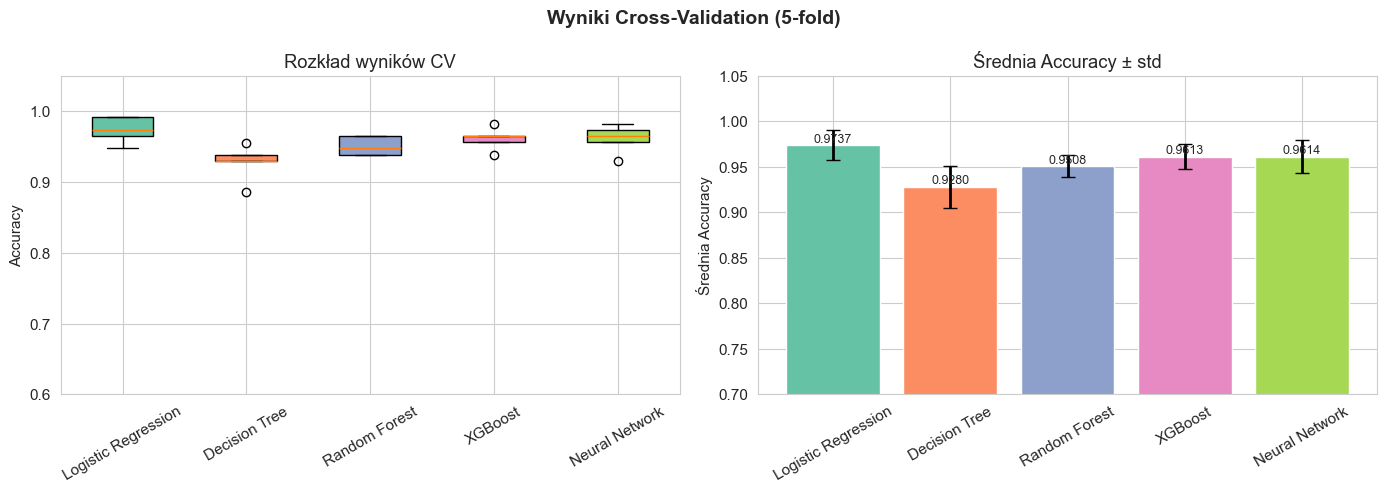


📊 Podsumowanie CV:


,Mean Accuracy,Std
Model,,
Logistic Regression,0.9737,0.0166
Decision Tree,0.9280,0.0230
Random Forest,0.9508,0.0118
XGBoost,0.9613,0.0142
Neural Network,0.9614,0.0180


In [27]:
# Wizualizacja CV
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Wyniki Cross-Validation (5-fold)', fontsize=14, fontweight='bold')

# Box plot
cv_data = [cv_results[m] for m in cv_results]
cv_names = list(cv_results.keys())
bp = axes[0].boxplot(cv_data, labels=cv_names, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
axes[0].set_ylabel('Accuracy'); axes[0].set_title('Rozkład wyników CV')
axes[0].tick_params(axis='x', rotation=30); axes[0].set_ylim(0.6, 1.05)

# Średnia ± odchylenie
means = [cv_results[m].mean() for m in cv_results]
stds = [cv_results[m].std() for m in cv_results]
x = np.arange(len(cv_names))
bars = axes[1].bar(x, means, color=COLORS[:len(cv_names)], edgecolor='white')
axes[1].errorbar(x, means, yerr=stds, fmt='none', color='black', capsize=5, linewidth=2)
axes[1].set_xticks(x); axes[1].set_xticklabels(cv_names, rotation=30)
axes[1].set_ylabel('Średnia Accuracy'); axes[1].set_title('Średnia Accuracy ± std')
axes[1].set_ylim(0.7, 1.05)
for bar, mean in zip(bars, means):
    axes[1].annotate(f'{mean:.4f}', (bar.get_x() + bar.get_width()/2, mean),
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

cv_df = pd.DataFrame({'Model': cv_names,
                       'Mean Accuracy': means,
                       'Std': stds}).set_index('Model')
print('\n📊 Podsumowanie CV:')
display(cv_df.style.format('{:.4f}').background_gradient(cmap='YlOrRd'))

## 9. Finalne porównanie wszystkich modeli


🏆 Finalne porównanie wszystkich modeli na zbiorze testowym:


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.9651,0.9811,0.9630,0.9720,0.9948
Decision Tree,0.9302,0.9615,0.9259,0.9434,0.9062
Random Forest,0.9419,0.9623,0.9444,0.9533,0.9896
XGBoost,0.9535,0.9808,0.9444,0.9623,0.9936
Neural Network,0.9302,0.9800,0.9074,0.9423,0.9919


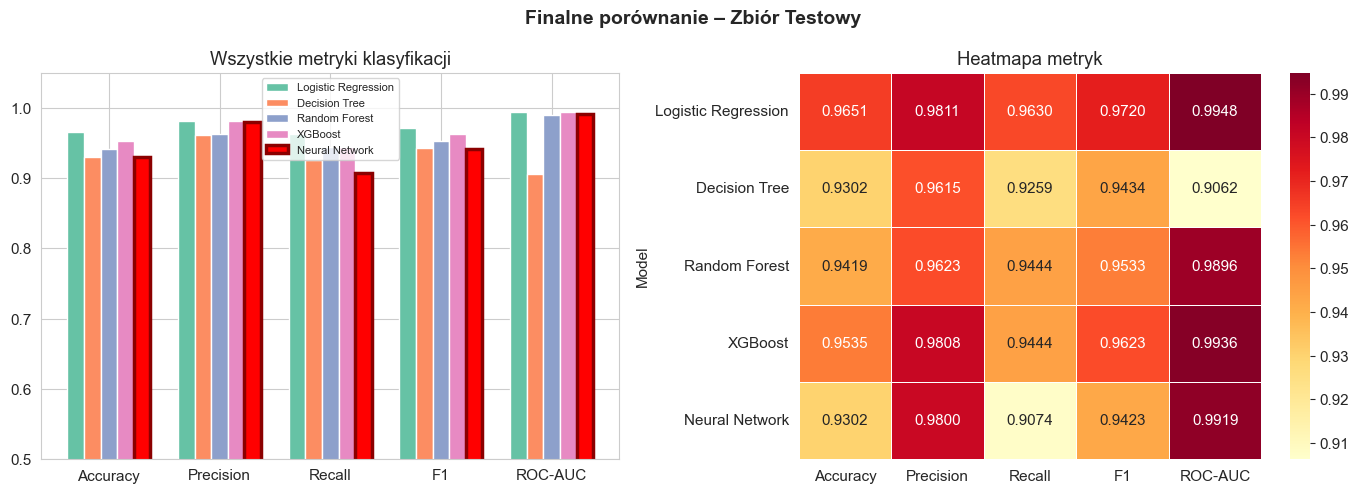

In [28]:
final_comparison = all_results_df.copy()

print('🏆 Finalne porównanie wszystkich modeli na zbiorze testowym:')
display(final_comparison.style
        .format('{:.4f}')
        .background_gradient(cmap='YlOrRd', axis=0)
        .highlight_max(color='lightgreen'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Finalne porównanie – Zbiór Testowy', fontsize=14, fontweight='bold')

# Wszystkie metryki
metrics_cols2 = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metrics_cols2))
width = 0.15
all_models = list(final_comparison.index)
for i, model_name in enumerate(all_models):
    color = 'red' if model_name == 'Neural Network' else COLORS[i % len(COLORS)]
    lw = 2.5 if model_name == 'Neural Network' else 1
    axes[0].bar(x + i*width, final_comparison.loc[model_name, metrics_cols2],
               width, label=model_name, color=color,
               edgecolor='white' if model_name != 'Neural Network' else 'darkred',
               linewidth=lw)
axes[0].set_xticks(x + width*2)
axes[0].set_xticklabels(metrics_cols2)
axes[0].set_ylim(0.5, 1.05)
axes[0].legend(fontsize=8)
axes[0].set_title('Wszystkie metryki klasyfikacji')

# Heatmapa
sns.heatmap(final_comparison[metrics_cols2].astype(float), annot=True, fmt='.4f',
            cmap='YlOrRd', ax=axes[1], linewidths=0.5)
axes[1].set_title('Heatmapa metryk')

plt.tight_layout()
plt.show()

## 10. Wnioski końcowe

In [29]:
# --- EKSTREMALNIE DYNAMICZNE WNIOSKI KOŃCOWE ---

# Przygotowanie danych
nn_metrics = final_comparison.loc['Neural Network']
lr_metrics = final_comparison.loc['Logistic Regression']
rf_metrics = final_comparison.loc['Random Forest']
xgb_metrics = final_comparison.loc['XGBoost']

best_model_acc = final_comparison['Accuracy'].idxmax()
best_acc_val = final_comparison['Accuracy'].max()

print('=' * 75)
print('   🏥 SYSTEMOWY RAPORT DIAGNOSTYCZNY: AI VS MODELE KLASYCZNE')
print('=' * 75)

# 1. BEZPOŚREDNIE STARCIE: DNN vs REGRESJA LOGISTYCZNA (Starcie Tytanów)
print(f'⚔️  POJEDYNEK: Sieć Neuronowa (DNN) vs Regresja Logistyczna (LR)')
if nn_metrics['Accuracy'] > lr_metrics['Accuracy']:
    diff = nn_metrics['Accuracy'] - lr_metrics['Accuracy']
    print(f'   • ZWYCIĘZCA: DNN wygrywa o {diff:.4f} pkt. Złożoność sieci przynosi korzyść.')
elif nn_metrics['Accuracy'] == lr_metrics['Accuracy']:
    print(f'   • REMIS: Oba modele mają identyczną celność ({nn_metrics["Accuracy"]:.4f}).')
    print(f'     WNIOSKIEM: Wybierz Regresję Logistyczną (zasada prostoty i interpretowalności).')
else:
    diff = lr_metrics['Accuracy'] - nn_metrics['Accuracy']
    print(f'   • ZWYCIĘZCA: Regresja Logistyczna bije DNN o {diff:.4f} pkt!')
    print(f'     DIAGNOZA: Dane są separowalne liniowo. Sieć neuronowa jest tutaj "strzelaniem z armaty do muchy".')

# 2. ANALIZA RYZYKA (Recall - kluczowe w medycynie)
print(f'\n🛡️  ANALIZA BEZPIECZEŃSTWA (Recall/Czułość):')
models_recall = final_comparison['Recall'].sort_values(ascending=False)
top_recall_model = models_recall.idxmax()

print(f'   • Najbezpieczniejszy model: {top_recall_model} (Recall: {models_recall.max():.4f})')
if top_recall_model == 'Neural Network':
    print('   • DNN najlepiej minimalizuje ryzyko przeoczenia nowotworu (False Negatives).')
else:
    print(f'   • UWAGA: {top_recall_model} lepiej wykrywa chorych niż Sieć Neuronowa!')

# 3. DNN VS ENSEMBLE (Random Forest / XGBoost)
print(f'\n🌲 DNN VS MODELE DRZEWIASTE (XGBoost/RF):')
best_tree_model = 'XGBoost' if xgb_metrics['Accuracy'] > rf_metrics['Accuracy'] else 'Random Forest'
tree_acc = final_comparison.loc[best_tree_model, 'Accuracy']

if nn_metrics['Accuracy'] > tree_acc:
    print(f'   • DNN pokonuje potężny {best_tree_model}. Sieć lepiej wyłapała nieliniowe korelacje.')
else:
    print(f'   • {best_tree_model} ({tree_acc:.4f}) wygrywa z DNN ({nn_metrics["Accuracy"]:.4f}).')
    print('     Modele bazujące na drzewach lepiej radzą sobie z tymi cechami tabelarycznymi.')

# 4. OCENA STABILNOŚCI I ARCHITEKTURY
print(f'\n📈 STABILNOŚĆ I ZŁOŻONOŚĆ:')
cv_std = np.std(nn_cv_scores)
if cv_std < 0.015:
    print(f'   • CV Standard Deviation ({cv_std:.4f}): Wyjątkowa stabilność. Modelowi można ufać.')
else:
    print(f'   • CV Standard Deviation ({cv_std:.4f}): Wysoka wariancja. Wyniki mogą zależeć od losowości danych.')

# 5. WERDYKT KOŃCOWY
print('\n🏁 WERDYKT OSTATECZNY:')
if best_model_acc == 'Neural Network' and nn_metrics['Recall'] >= 0.96:
    print(f'   🌟 REKOMENDACJA: Wdrażaj DNN. Jest bezkonkurencyjna w tym zestawie parametrów.')
elif 'Logistic Regression' in best_model_acc or lr_metrics['Accuracy'] >= nn_metrics['Accuracy'] - 0.005:
     print(f'   ⚖️  REKOMENDACJA: Wybierz Regresję Logistyczną. Wyniki są zbyt zbliżone, by uzasadnić')
     print(f'      użycie skomplikowanej Sieci Neuronowej.')
else:
    print(f'   🛠️  REKOMENDACJA: Najlepszy wynik dał {best_model_acc}. Rozważ użycie tego modelu.')

print('=' * 75)

   🏥 SYSTEMOWY RAPORT DIAGNOSTYCZNY: AI VS MODELE KLASYCZNE
⚔️  POJEDYNEK: Sieć Neuronowa (DNN) vs Regresja Logistyczna (LR)
   • ZWYCIĘZCA: Regresja Logistyczna bije DNN o 0.0349 pkt!
     DIAGNOZA: Dane są separowalne liniowo. Sieć neuronowa jest tutaj "strzelaniem z armaty do muchy".

🛡️  ANALIZA BEZPIECZEŃSTWA (Recall/Czułość):
   • Najbezpieczniejszy model: Logistic Regression (Recall: 0.9630)
   • UWAGA: Logistic Regression lepiej wykrywa chorych niż Sieć Neuronowa!

🌲 DNN VS MODELE DRZEWIASTE (XGBoost/RF):
   • XGBoost (0.9535) wygrywa z DNN (0.9302).
     Modele bazujące na drzewach lepiej radzą sobie z tymi cechami tabelarycznymi.

📈 STABILNOŚĆ I ZŁOŻONOŚĆ:
   • CV Standard Deviation (0.0180): Wysoka wariancja. Wyniki mogą zależeć od losowości danych.

🏁 WERDYKT OSTATECZNY:
   ⚖️  REKOMENDACJA: Wybierz Regresję Logistyczną. Wyniki są zbyt zbliżone, by uzasadnić
      użycie skomplikowanej Sieci Neuronowej.
